In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, GridSearchCV

# Carregar os dados
housing = pd.read_csv('housing.zip')

# Obter as primeiras linhas do conjunto de dados
print(housing.head())

# Descrição sumária dos dados
print(housing.describe())

# Sumário de cada atributo
print(housing.info())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
          longitude      latitude  housing_median_age   total_rooms  \
coun

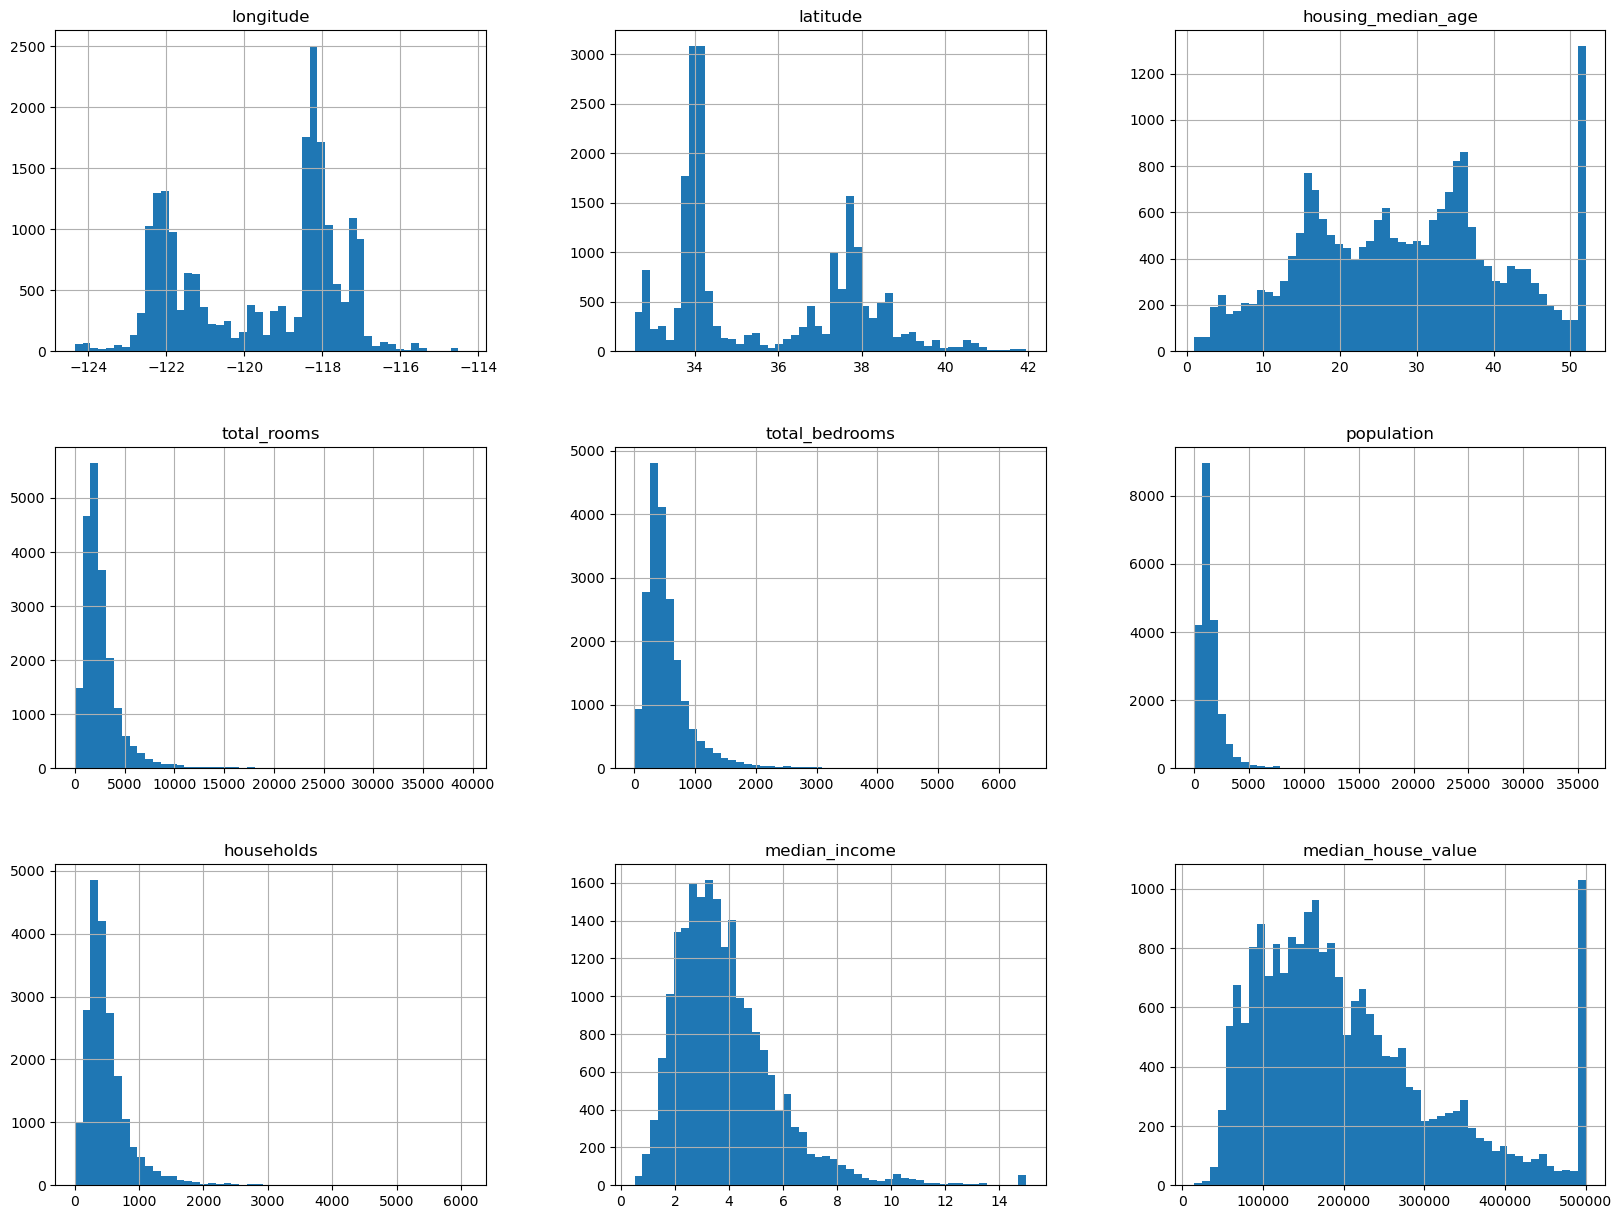

In [4]:
# Histograma dos atributos numéricos
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [5]:
# Criação de conjuntos de treino e teste (80-20%)
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

# Proporção de exemplos nos conjuntos completo, treino e teste assumindo 5 categorias do salário médio
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])
print(housing["income_cat"].value_counts() / len(housing))

train_set["income_cat"] = pd.cut(train_set["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])
print(train_set["income_cat"].value_counts() / len(train_set))

test_set["income_cat"] = pd.cut(test_set["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])
print(test_set["income_cat"].value_counts() / len(test_set))

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64
income_cat
3    0.348595
2    0.317466
4    0.178537
5    0.115673
1    0.039729
Name: count, dtype: float64
income_cat
3    0.358527
2    0.324370
4    0.167393
5    0.109496
1    0.040213
Name: count, dtype: float64


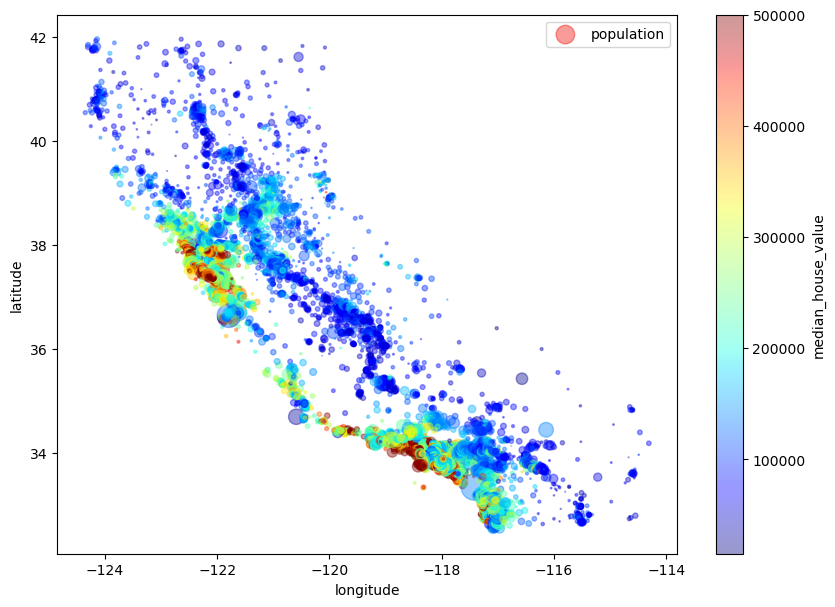

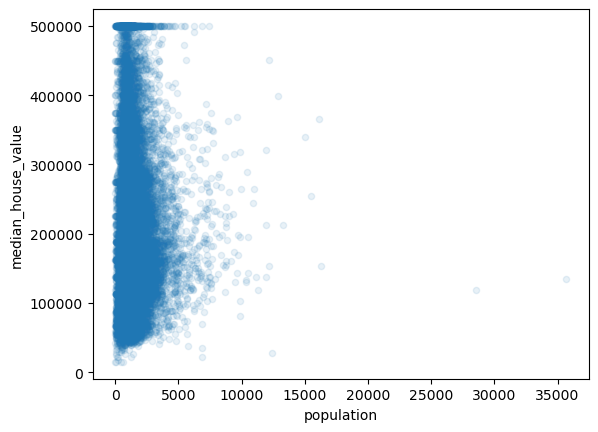

In [6]:
# Gráfico de dispersão para verificar áreas mais densas
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4, s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)
plt.legend()
plt.show()

# Relacionar a população com o preço mediano
housing.plot(kind="scatter", x="population", y="median_house_value", alpha=0.1)
plt.show()

In [12]:
X = housing.drop(columns =[ 'ocean_proximity'])
# Calcular o coeficiente de correlação entre os atributos
corr_matrix = X.corr()
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688075
income_cat            0.643892
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


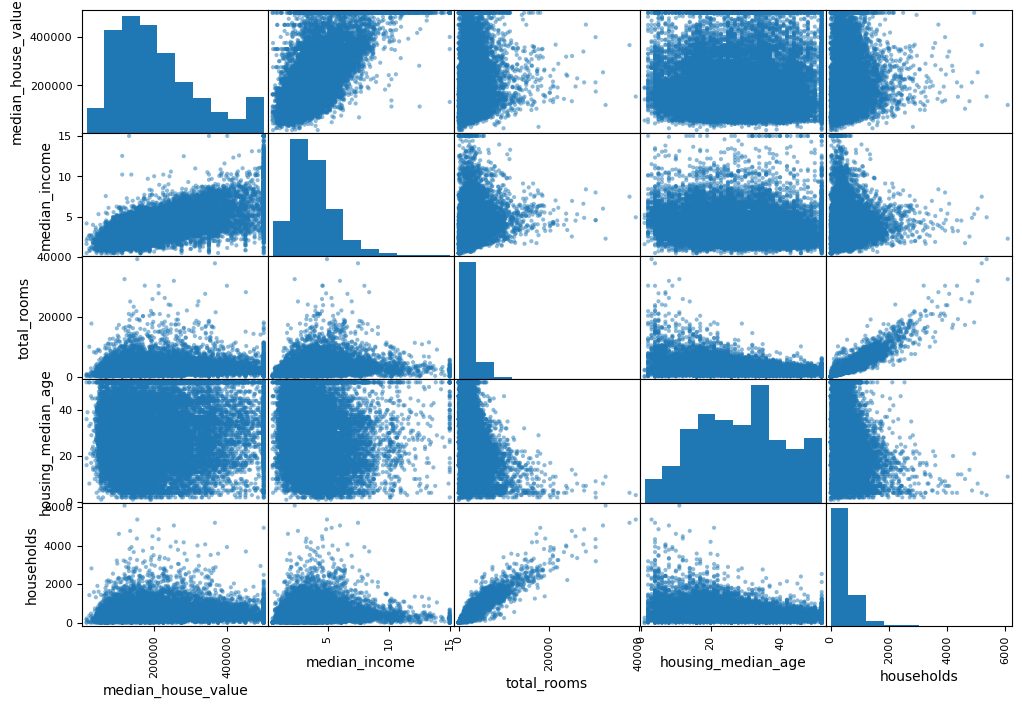

In [13]:
# scatter_matrix dos 5 atributos com maior correlação
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age", "households"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

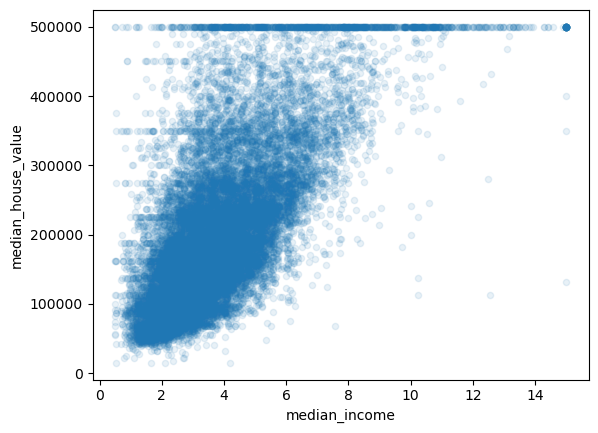

In [14]:
# Gráfico de dispersão da correlação mais alta
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)
plt.show()

In [15]:
# Verificar valores em falta
print(housing.isnull().sum())

# Substituir valores em falta pela mediana
imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity", axis=1)
imputer.fit(housing_num)
housing_num = pd.DataFrame(imputer.transform(housing_num), columns=housing_num.columns)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
income_cat              0
dtype: int64


In [16]:
# Transformar "ocean_proximity" em atributo numérico usando OneHotEncoder
housing_cat = housing[["ocean_proximity"]]
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot = pd.DataFrame(housing_cat_1hot.toarray(), columns=cat_encoder.categories_[0])

# Concatenar os dados numéricos e categóricos
housing_prepared = housing_num.join(housing_cat_1hot)

In [17]:
# Uniformizar os dados usando StandardScaler
scaler = StandardScaler()
housing_prepared = pd.DataFrame(scaler.fit_transform(housing_prepared), columns=housing_prepared.columns)

In [18]:
# Função para exibir os scores dos modelos
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

# Regressão Linear
lin_reg = LinearRegression()
lin_scores = cross_val_score(lin_reg, housing_prepared, housing["median_house_value"], scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
print("Linear Regression:")
display_scores(lin_rmse_scores)

# Regressão Ridge
ridge_reg = Ridge()
ridge_scores = cross_val_score(ridge_reg, housing_prepared, housing["median_house_value"], scoring="neg_mean_squared_error", cv=10)
ridge_rmse_scores = np.sqrt(-ridge_scores)
print("Ridge Regression:")
display_scores(ridge_rmse_scores)

# Regressão Lasso
lasso_reg = Lasso()
lasso_scores = cross_val_score(lasso_reg, housing_prepared, housing["median_house_value"], scoring="neg_mean_squared_error", cv=10)
lasso_rmse_scores = np.sqrt(-lasso_scores)
print("Lasso Regression:")
display_scores(lasso_rmse_scores)

# Regressão com Descida de Gradiente Estocástica
sgd_reg = SGDRegressor()
sgd_scores = cross_val_score(sgd_reg, housing_prepared, housing["median_house_value"], scoring="neg_mean_squared_error", cv=10)
sgd_rmse_scores = np.sqrt(-sgd_scores)
print("SGD Regression:")
display_scores(sgd_rmse_scores)

# Regressão Polinomial Grau 2
poly_features = PolynomialFeatures(degree=2, include_bias=False)
housing_poly = poly_features.fit_transform(housing_prepared)
lin_reg_poly = LinearRegression()
poly_scores = cross_val_score(lin_reg_poly, housing_poly, housing["median_house_value"], scoring="neg_mean_squared_error", cv=10)
poly_rmse_scores = np.sqrt(-poly_scores)
print("Polynomial Regression Degree 2:")
display_scores(poly_rmse_scores)

Linear Regression:
Scores: [7.21549645e-11 1.07504601e-10 2.92571944e-10 1.22556358e-10
 9.21546329e+02 2.01194096e-10 1.28102449e-10 5.38731275e-10
 1.11990875e-10 8.27283323e-11]
Mean: 92.15463290198008
Standard deviation: 276.4638987053877
Ridge Regression:
Scores: [13.08965079  8.90397249 14.23948908  9.34755969 12.69906031 10.67721667
  7.69808899 14.91544831 12.13516444  7.96459275]
Mean: 11.167024352163399
Standard deviation: 2.478557869629194
Lasso Regression:
Scores: [47.44980635 56.8867548  32.83054429 30.19358151 52.1170585  44.97317291
 49.65661064 38.05050962 84.04600221 52.1262276 ]
Mean: 48.83302684378939
Standard deviation: 14.3656093246345
SGD Regression:
Scores: [1.29537735e+09 1.20933000e+08 4.13043896e+08 1.50816900e+08
 9.86931833e+03 2.62061153e+08 4.89756192e+08 3.84872882e+08
 3.68488973e+08 1.26504933e+08]
Mean: 361186514.466588
Standard deviation: 344945387.77483326
Polynomial Regression Degree 2:
Scores: [1.30976821e-09 6.26477199e-10 1.35345204e-08 6.4454587

In [19]:
# Divisão do conjunto de treino em treino e validação (80-20%)
train_set, val_set = train_test_split(train_set, test_size=0.2, random_state=42)
train_prepared = housing_prepared.loc[train_set.index]
val_prepared = housing_prepared.loc[val_set.index]

from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(random_state=42)
elastic_net.fit(train_prepared, train_set["median_house_value"])

# Verificação do erro no conjunto de treino e validação
train_predictions = elastic_net.predict(train_prepared)
val_predictions = elastic_net.predict(val_prepared)

from sklearn.metrics import mean_squared_error
train_mse = mean_squared_error(train_set["median_house_value"], train_predictions)
val_mse = mean_squared_error(val_set["median_house_value"], val_predictions)
train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)

print("Elastic Net - Train RMSE:", train_rmse)
print("Elastic Net - Validation RMSE:", val_rmse)

# Fine-tuning usando Grid Search
param_grid = [
    {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.1, 0.5, 0.9]},
]

grid_search = GridSearchCV(elastic_net, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(train_prepared, train_set["median_house_value"])

print("Best parameters:", grid_search.best_params_)
print("Best estimator:", grid_search.best_estimator_)

# Avaliação no conjunto de teste
final_model = grid_search.best_estimator_
test_prepared = housing_prepared.loc[test_set.index]
final_predictions = final_model.predict(test_prepared)
final_mse = mean_squared_error(test_set["median_house_value"], final_predictions)
final_rmse = np.sqrt(final_mse)

print("Final model - Test RMSE:", final_rmse)

Elastic Net - Train RMSE: 36602.62428247127
Elastic Net - Validation RMSE: 37555.2698123041
Best parameters: {'alpha': 0.1, 'l1_ratio': 0.9}
Best estimator: ElasticNet(alpha=0.1, l1_ratio=0.9, random_state=42)
Final model - Test RMSE: 1905.5596572040472
